<a href="https://colab.research.google.com/github/sharvani1357/Transformers/blob/main/TRANSFORMERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn


In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download(
    "dhruvildave/en-fr-translation-dataset"
)

print("Dataset Path:", path)

print(os.listdir(path))

Using Colab cache for faster access to the 'en-fr-translation-dataset' dataset.
Dataset Path: /kaggle/input/en-fr-translation-dataset
['en-fr.csv']


In [ ]:
import pandas as pd
import os

csv_file = os.path.join(path, "en-fr.csv")

chunk_size = 50000

for chunk in pd.read_csv(csv_file, chunksize=chunk_size):
    print(chunk.shape)
    df = chunk
    break

(50000, 2)


Step 2: Select Required Columns

In [ ]:
df = df[['en', 'fr']]

df.dropna(inplace=True)

print(df.head())

                                                  en  \
0  Changing Lives | Changing Society | How It Wor...   
1                                           Site map   
2                                           Feedback   
3                                            Credits   
4                                           Français   

                                                  fr  
0  Il a transformé notre vie | Il a transformé la...  
1                                       Plan du site  
2                                        Rétroaction  
3                                            Crédits  
4                                            English  


Step 3: Convert Text to Lowercase

In [ ]:
df['en'] = df['en'].str.lower()
df['fr'] = df['fr'].str.lower()

print(df.head())

                                                  en  \
0  changing lives | changing society | how it wor...   
1                                           site map   
2                                           feedback   
3                                            credits   
4                                           français   

                                                  fr  
0  il a transformé notre vie | il a transformé la...  
1                                       plan du site  
2                                        rétroaction  
3                                            crédits  
4                                            english  


Step 4: Remove Unnecessary Symbols

In [ ]:
import re

def clean_text(text):
    text = re.sub(r"[^a-zA-ZÀ-ÿ\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df['en'] = df['en'].apply(clean_text)
df['fr'] = df['fr'].apply(clean_text)

print(df.head())

                                                  en  \
0  changing lives changing society how it works t...   
1                                           site map   
2                                           feedback   
3                                            credits   
4                                           français   

                                                  fr  
0  il a transformé notre vie il a transformé la s...  
1                                       plan du site  
2                                        rétroaction  
3                                            crédits  
4                                            english  


Step 5: Add Special Tokens

In [ ]:
df['fr'] = "<start> " + df['fr'] + " <end>"

In [ ]:
print(df['fr'].iloc[0])

<start> il a transformé notre vie il a transformé la société son fonctionnement la technologie moteur du changement accueil concepts enseignants recherche aperçu collaborateurs web hhcc ressources commentaires musée virtuel du canada <end>


Step 6: Create Source and Target Sentences

In [ ]:
english_sentences = df['en'].tolist()
french_sentences = df['fr'].tolist()

print("English:")
print(english_sentences[0])

print("\nFrench:")
print(french_sentences[0])

English:
changing lives changing society how it works technology drives change home concepts teachers search overview credits hhcc web reference feedback virtual museum of canada home page

French:
<start> il a transformé notre vie il a transformé la société son fonctionnement la technologie moteur du changement accueil concepts enseignants recherche aperçu collaborateurs web hhcc ressources commentaires musée virtuel du canada <end>


Step 7: Create Source and Target Vocabularies

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

eng_tokenizer = Tokenizer(filters='')
fr_tokenizer = Tokenizer(filters='')

eng_tokenizer.fit_on_texts(english_sentences)
fr_tokenizer.fit_on_texts(french_sentences)

In [ ]:
eng_vocab_size = len(eng_tokenizer.word_index) + 1
fr_vocab_size = len(fr_tokenizer.word_index) + 1

print("English Vocabulary Size:", eng_vocab_size)
print("French Vocabulary Size:", fr_vocab_size)

English Vocabulary Size: 34395
French Vocabulary Size: 41866


Step 8: Convert Words into Integer Tokens

In [ ]:
eng_sequences = eng_tokenizer.texts_to_sequences(
    english_sentences
)

fr_sequences = fr_tokenizer.texts_to_sequences(
    french_sentences
)

In [ ]:
print("English Sentence:")
print(english_sentences[0])

print("\nTokenized:")
print(eng_sequences[0])

print("\nFrench Sentence:")
print(french_sentences[0])

print("\nTokenized:")
print(fr_sequences[0])

English Sentence:
changing lives changing society how it works technology drives change home concepts teachers search overview credits hhcc web reference feedback virtual museum of canada home page

Tokenized:
[1391, 3553, 1391, 1297, 630, 30, 1982, 347, 7856, 536, 560, 3657, 7857, 2230, 292, 4388, 18234, 355, 834, 3746, 2264, 9664, 3, 19, 560, 1129]

French Sentence:
<start> il a transformé notre vie il a transformé la société son fonctionnement la technologie moteur du changement accueil concepts enseignants recherche aperçu collaborateurs web hhcc ressources commentaires musée virtuel du canada <end>

Tokenized:
[2, 34, 23, 1891, 608, 506, 34, 23, 1891, 6, 385, 69, 4221, 6, 574, 3737, 11, 1364, 6359, 4686, 8804, 180, 303, 5534, 227, 22799, 416, 2294, 12054, 3652, 11, 25, 3]


###Task 2: Embedding Layer

Objective

Convert tokens into dense vectors.

Example:

The    → [0.12, 0.78, 0.43]

cat    → [0.81, 0.23, 0.55]

mouse  → [0.45, 0.61, 0.77]

Deliverables

Explain:
Why embeddings are required.  
Difference between One-Hot Encoding and Embeddings.


In [ ]:
# =====================================
# TASK 2: EMBEDDING LAYER
# =====================================

import tensorflow as tf
from tensorflow.keras.layers import Embedding

# Embedding dimension
embedding_dim = 128

# English Embedding Layer
eng_embedding = Embedding(
    input_dim=eng_vocab_size,
    output_dim=embedding_dim,
    mask_zero=True
)

# French Embedding Layer
fr_embedding = Embedding(
    input_dim=fr_vocab_size,
    output_dim=embedding_dim,
    mask_zero=True
)

# -------------------------------------
# Example: Convert Token IDs to Vectors
# -------------------------------------

sample_eng_tokens = tf.constant([eng_sequences[0]])

embedded_output = eng_embedding(sample_eng_tokens)

print("Original Token IDs:")
print(sample_eng_tokens)

print("\nEmbedding Shape:")
print(embedded_output.shape)

print("\nFirst Word Embedding Vector:")
print(embedded_output[0][0])

Original Token IDs:
tf.Tensor(
[[ 1391  3553  1391  1297   630    30  1982   347  7856   536   560  3657
   7857  2230   292  4388 18234   355   834  3746  2264  9664     3    19
    560  1129]], shape=(1, 26), dtype=int32)

Embedding Shape:
(1, 26, 128)

First Word Embedding Vector:
tf.Tensor(
[-0.00683894 -0.01123173 -0.01564693 -0.04831296 -0.0188502  -0.03530158
  0.02522058 -0.0304208   0.01725919  0.04483041  0.02948527  0.0270322
  0.0380105  -0.01643733  0.03123173 -0.0377906  -0.02678176  0.03590497
 -0.01403455  0.02244827  0.04311304 -0.04366336  0.03834682 -0.00590017
  0.04274834  0.00217194 -0.01611678  0.00518198 -0.0034252  -0.02705574
  0.04321226  0.03288534  0.02685945  0.00891676  0.00153913  0.0433345
 -0.04127015 -0.03140184 -0.04662487  0.00401118  0.04394201 -0.03551998
  0.01552497  0.0056849   0.01005369  0.01541374  0.04510696  0.04474937
  0.02635253 -0.03631604 -0.00227449  0.04764901 -0.01901437  0.04117305
 -0.00871785  0.01525155  0.04013987  0.04972968 

The Embedding Layer is the first learnable layer of a Transformer. It converts token IDs into dense numerical vectors that preserve semantic relationships, enabling the model to understand language more effectively than One-Hot Encoding.

###Task 3: Positional Encoding



In [ ]:
# =====================================
# TASK 3: POSITIONAL ENCODING
# =====================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------------------
# Positional Encoding Function
# -----------------------------

def positional_encoding(max_position, d_model):

    pos_encoding = np.zeros((max_position, d_model))

    for pos in range(max_position):

        for i in range(0, d_model, 2):

            angle = pos / np.power(10000, (2 * i) / d_model)

            pos_encoding[pos, i] = np.sin(angle)

            if i + 1 < d_model:
                pos_encoding[pos, i + 1] = np.cos(angle)

    return tf.cast(pos_encoding, dtype=tf.float32)

# -----------------------------
# Generate Positional Encoding
# -----------------------------

max_length = 50
d_model = embedding_dim

pos_encoding = positional_encoding(
    max_length,
    d_model
)

print("Positional Encoding Shape:")
print(pos_encoding.shape)

Positional Encoding Shape:
(50, 128)


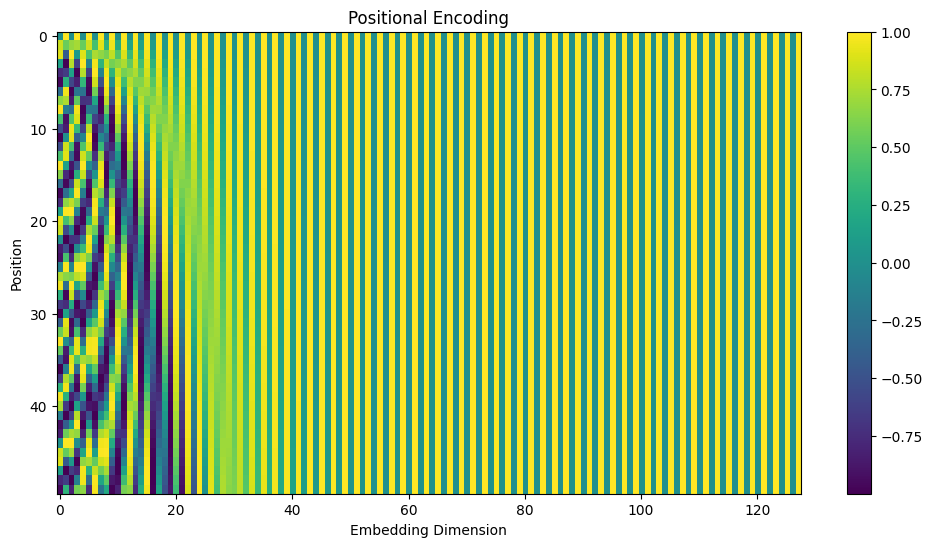

In [ ]:
# --------------------------------
# Heatmap Visualization
# --------------------------------

plt.figure(figsize=(12,6))

plt.imshow(
    pos_encoding.numpy(),
    aspect='auto',
    cmap='viridis'
)

plt.colorbar()

plt.xlabel("Embedding Dimension")
plt.ylabel("Position")

plt.title("Positional Encoding")

plt.show()

Sentence:
changing lives changing society how it works technology drives change home concepts teachers search overview credits hhcc web reference feedback virtual museum of canada home page

Token IDs:
[[ 1391  3553  1391  1297   630    30  1982   347  7856   536   560  3657
   7857  2230   292  4388 18234   355   834  3746  2264  9664     3    19
    560  1129]]

Embedding Shape:
(1, 26, 128)

Transformer Input Shape:
(1, 26, 128)

Q Shape: (1, 26, 128)
K Shape: (1, 26, 128)
V Shape: (1, 26, 128)

Attention Matrix Shape:
(26, 26)

ATTENTION SCORES
[[-1.7440387 -1.7848773 -1.7037587 -1.5488566 -1.4966518 -1.5267173
  -1.5925713 -1.5478995 -1.6001606 -1.5865917 -1.6348066 -1.7128015
  -1.7600217 -1.7447165 -1.6707038 -1.5764469 -1.5531195 -1.6222166
  -1.6612061 -1.7241194 -1.6308496 -1.5612203 -1.5373609 -1.5736474
  -1.7038091 -1.8314134]
 [-1.7615242 -1.8148472 -1.763555  -1.6055787 -1.5400747 -1.5465045
  -1.5833693 -1.5426495 -1.6148742 -1.6312091 -1.7001115 -1.7868792
  -1.8188425

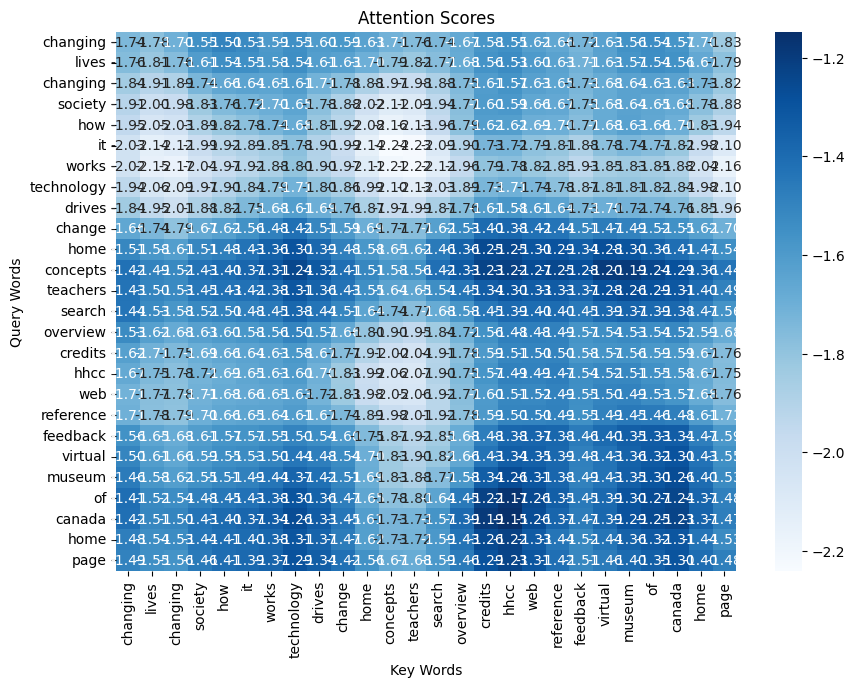

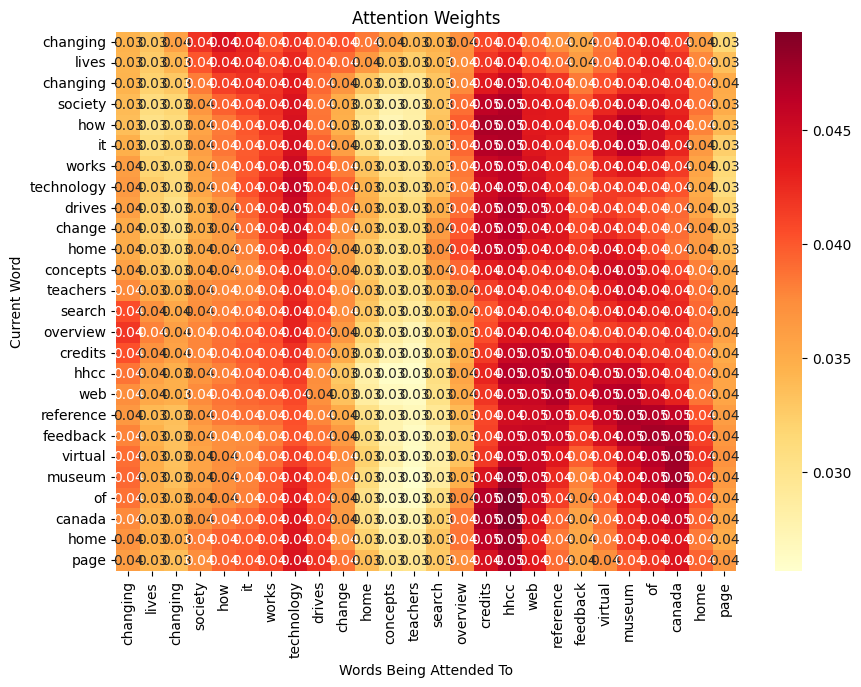

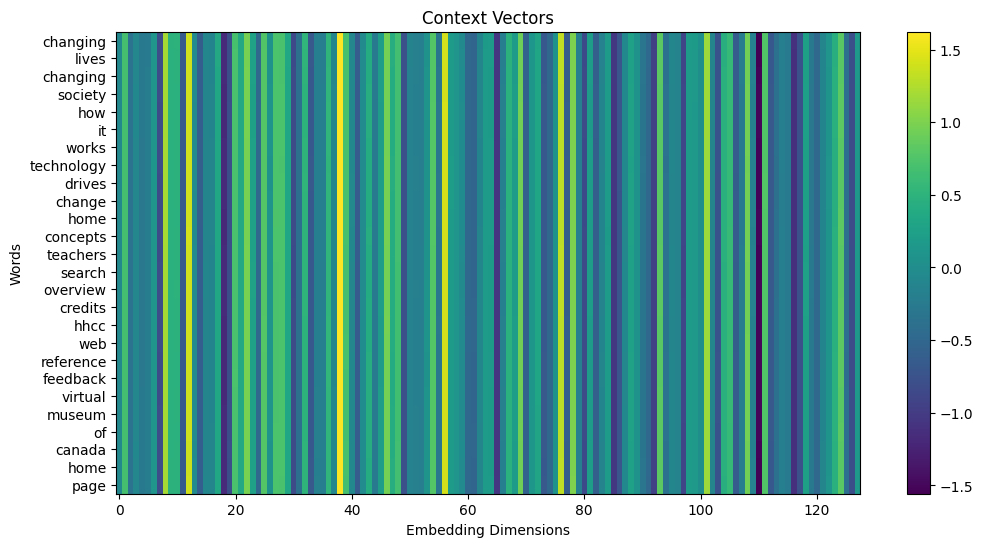


WORD ATTENTION ANALYSIS
'changing' attends most to 'how' with weight 0.0442
'lives' attends most to 'hhcc' with weight 0.0432
'changing' attends most to 'hhcc' with weight 0.0453
'society' attends most to 'hhcc' with weight 0.0469
'how' attends most to 'credits' with weight 0.0472
'it' attends most to 'hhcc' with weight 0.0469
'works' attends most to 'hhcc' with weight 0.0461
'technology' attends most to 'hhcc' with weight 0.0461
'drives' attends most to 'hhcc' with weight 0.0468
'change' attends most to 'hhcc' with weight 0.0464
'home' attends most to 'hhcc' with weight 0.0457
'concepts' attends most to 'museum' with weight 0.0451
'teachers' attends most to 'museum' with weight 0.0447
'search' attends most to 'museum' with weight 0.0435
'overview' attends most to 'web' with weight 0.0439
'credits' attends most to 'reference' with weight 0.0459
'hhcc' attends most to 'reference' with weight 0.0472
'web' attends most to 'reference' with weight 0.0468
'reference' attends most to 'museum

In [ ]:
# ============================================
# TASK 4: SCALED DOT PRODUCT ATTENTION
# ============================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# Use a Real Sentence From Dataset
# --------------------------------------------------

sample_sentence = english_sentences[0]

print("Sentence:")
print(sample_sentence)

words = sample_sentence.split()

# --------------------------------------------------
# Convert Sentence to Tokens
# --------------------------------------------------

token_ids = eng_tokenizer.texts_to_sequences(
    [sample_sentence]
)

token_ids = tf.constant(token_ids)

print("\nToken IDs:")
print(token_ids.numpy())

# --------------------------------------------------
# Embedding Layer Output
# --------------------------------------------------

embedded_sentence = eng_embedding(token_ids)

print("\nEmbedding Shape:")
print(embedded_sentence.shape)

# --------------------------------------------------
# Add Positional Encoding
# --------------------------------------------------

sequence_length = embedded_sentence.shape[1]

position_slice = pos_encoding[:sequence_length]

transformer_input = embedded_sentence + position_slice

print("\nTransformer Input Shape:")
print(transformer_input.shape)

# --------------------------------------------------
# Create Q, K, V
# --------------------------------------------------

d_model = embedding_dim

Wq = tf.keras.layers.Dense(d_model)
Wk = tf.keras.layers.Dense(d_model)
Wv = tf.keras.layers.Dense(d_model)

Q = Wq(transformer_input)
K = Wk(transformer_input)
V = Wv(transformer_input)

print("\nQ Shape:", Q.shape)
print("K Shape:", K.shape)
print("V Shape:", V.shape)

# --------------------------------------------------
# Scaled Dot Product Attention
# --------------------------------------------------

def scaled_dot_product_attention(Q, K, V):

    matmul_qk = tf.matmul(
        Q,
        K,
        transpose_b=True
    )

    dk = tf.cast(
        tf.shape(K)[-1],
        tf.float32
    )

    scaled_attention_logits = (
        matmul_qk /
        tf.math.sqrt(dk)
    )

    attention_weights = tf.nn.softmax(
        scaled_attention_logits,
        axis=-1
    )

    context_vectors = tf.matmul(
        attention_weights,
        V
    )

    return (
        scaled_attention_logits,
        attention_weights,
        context_vectors
    )

# --------------------------------------------------
# Apply Attention
# --------------------------------------------------

scores, attention_weights, context_vectors = (
    scaled_dot_product_attention(
        Q,
        K,
        V
    )
)

# --------------------------------------------------
# Convert To Numpy
# --------------------------------------------------

scores = scores[0].numpy()
attention_weights = attention_weights[0].numpy()
context_vectors = context_vectors[0].numpy()

actual_length = attention_weights.shape[0]

words = words[:actual_length]

print("\nAttention Matrix Shape:")
print(attention_weights.shape)

# --------------------------------------------------
# Attention Scores
# --------------------------------------------------

print("\n==============================")
print("ATTENTION SCORES")
print("==============================")

print(scores)

# --------------------------------------------------
# Attention Weights
# --------------------------------------------------

print("\n==============================")
print("ATTENTION WEIGHTS")
print("==============================")

print(attention_weights)

# --------------------------------------------------
# Context Vectors
# --------------------------------------------------

print("\n==============================")
print("CONTEXT VECTOR SHAPE")
print("==============================")

print(context_vectors.shape)

# --------------------------------------------------
# Heatmap: Attention Scores
# --------------------------------------------------

plt.figure(figsize=(10,7))

sns.heatmap(
    scores,
    xticklabels=words,
    yticklabels=words,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Attention Scores")
plt.xlabel("Key Words")
plt.ylabel("Query Words")

plt.show()

# --------------------------------------------------
# Heatmap: Attention Weights
# --------------------------------------------------

plt.figure(figsize=(10,7))

sns.heatmap(
    attention_weights,
    xticklabels=words,
    yticklabels=words,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)

plt.title("Attention Weights")
plt.xlabel("Words Being Attended To")
plt.ylabel("Current Word")

plt.show()

# --------------------------------------------------
# Context Vectors Visualization
# --------------------------------------------------

plt.figure(figsize=(12,6))

plt.imshow(
    context_vectors,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar()

plt.title("Context Vectors")

plt.xlabel("Embedding Dimensions")
plt.ylabel("Words")

plt.yticks(
    np.arange(len(words)),
    words
)

plt.show()

# --------------------------------------------------
# Word-to-Word Attention Analysis
# --------------------------------------------------

print("\n==============================")
print("WORD ATTENTION ANALYSIS")
print("==============================")

for i in range(actual_length):

    most_attended_index = np.argmax(
        attention_weights[i]
    )

    attended_word = words[
        most_attended_index
    ]

    print(
        f"'{words[i]}' attends most to "
        f"'{attended_word}' "
        f"with weight "
        f"{attention_weights[i][most_attended_index]:.4f}"
    )

# --------------------------------------------------
# Example Context Vector
# --------------------------------------------------

print("\nFirst Context Vector:")

print(
    context_vectors[0][:10]
)

# --------------------------------------------------
# Summary
# --------------------------------------------------

print("\n==============================")
print("TRANSFORMER ATTENTION FLOW")
print("==============================")

print("""
Sentence
    ↓
Tokenization
    ↓
Embeddings
    ↓
Positional Encoding
    ↓
Transformer Input
    ↓
Q, K, V
    ↓
QKᵀ
    ↓
Scale by √dk
    ↓
Softmax
    ↓
Attention Weights
    ↓
Weighted Sum of V
    ↓
Context Vectors
""")

Sentence:
changing lives changing society how it works technology drives change home concepts teachers search overview credits hhcc web reference feedback virtual museum of canada home page
Embedding Dimension: 128
Number of Heads: 4
Head Dimension: 32

Q Shape: (1, 4, 26, 32)
K Shape: (1, 4, 26, 32)
V Shape: (1, 4, 26, 32)

Attention Weights Shape:
(1, 4, 26, 26)

Context Vectors Shape:
(1, 4, 26, 32)


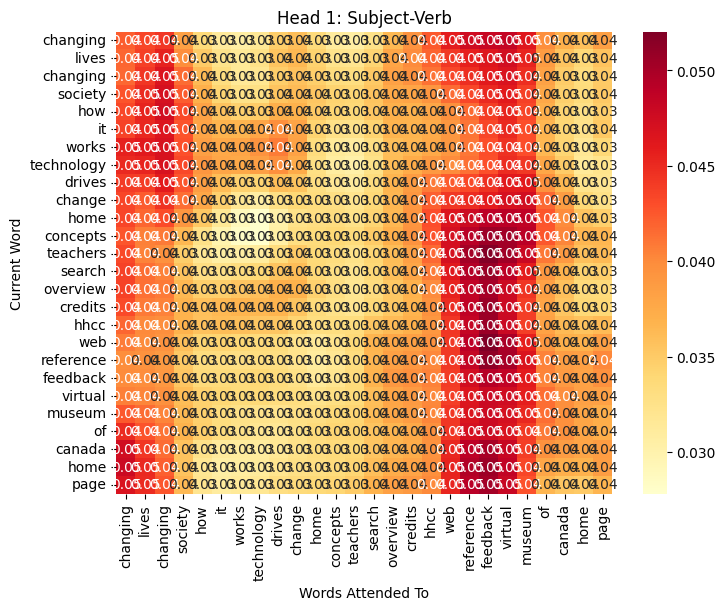

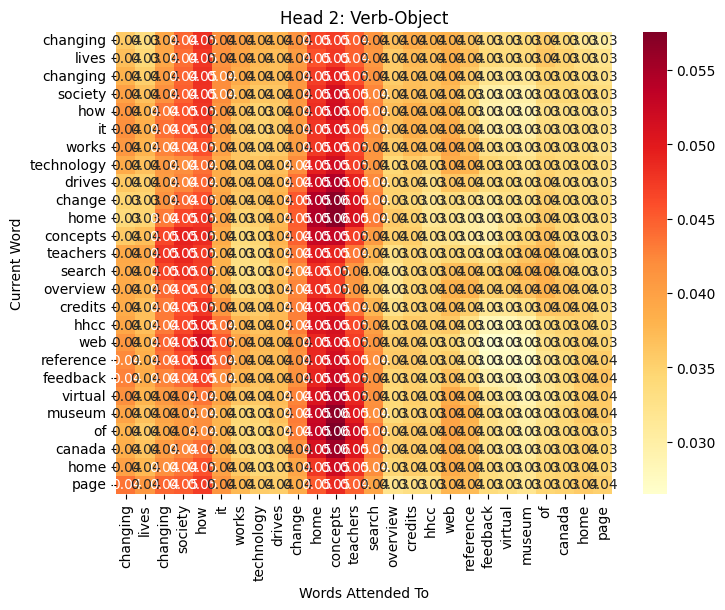

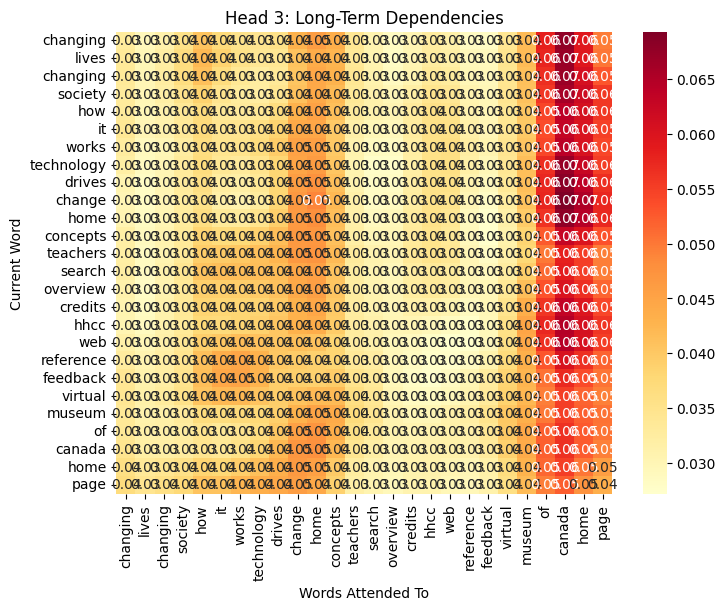

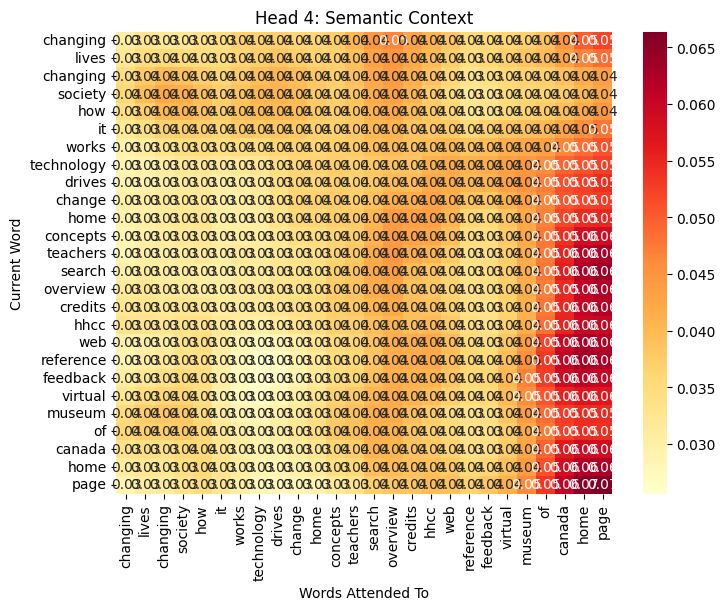


MULTI-HEAD ATTENTION ANALYSIS


Head 1: Subject-Verb
----------------------------------------
changing → virtual (0.048)
lives → virtual (0.047)
changing → virtual (0.047)
society → changing (0.047)
how → changing (0.047)
it → changing (0.047)
works → changing (0.047)
technology → changing (0.047)
drives → virtual (0.046)
change → museum (0.047)
home → virtual (0.049)
concepts → feedback (0.051)
teachers → feedback (0.052)
search → feedback (0.051)
overview → feedback (0.050)
credits → feedback (0.051)
hhcc → feedback (0.051)
web → feedback (0.052)
reference → feedback (0.051)
feedback → feedback (0.049)
virtual → feedback (0.048)
museum → feedback (0.048)
of → feedback (0.048)
canada → feedback (0.050)
home → feedback (0.051)
page → feedback (0.050)

Head 2: Verb-Object
----------------------------------------
changing → how (0.048)
lives → how (0.048)
changing → concepts (0.050)
society → concepts (0.051)
how → concepts (0.052)
it → concepts (0.050)
works → concepts (0.050)
technolo

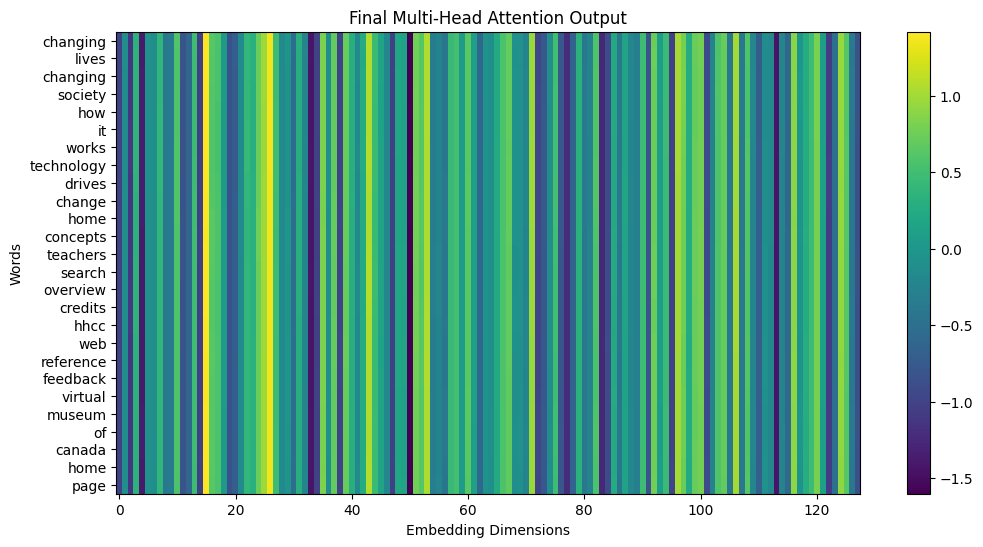


HEAD RESPONSIBILITIES


Head 1 → Subject-Verb Relationships
Example:
cat → chased

Head 2 → Verb-Object Relationships
Example:
chased → mouse

Head 3 → Long-Term Dependencies
Example:
the → mouse

Head 4 → Semantic Context
Example:
cat ↔ mouse

Different heads learn different linguistic
patterns simultaneously.

This is the key innovation of
Multi-Head Attention.


MULTI-HEAD ATTENTION FLOW

Transformer Input
       ↓
Linear Projection
       ↓
Q, K, V
       ↓
Split into 4 Heads
       ↓
Head 1 Attention
Head 2 Attention
Head 3 Attention
Head 4 Attention
       ↓
Concatenate Heads
       ↓
Final Output



In [ ]:
# ============================================
# TASK 5: MULTI-HEAD ATTENTION
# ============================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# Sample Sentence
# --------------------------------------------------

sample_sentence = english_sentences[0]

print("Sentence:")
print(sample_sentence)

words = sample_sentence.split()

# --------------------------------------------------
# Convert Sentence to Tokens
# --------------------------------------------------

token_ids = eng_tokenizer.texts_to_sequences(
    [sample_sentence]
)

token_ids = tf.constant(token_ids)

# --------------------------------------------------
# Embedding + Positional Encoding
# --------------------------------------------------

embedded_sentence = eng_embedding(token_ids)

sequence_length = embedded_sentence.shape[1]

position_slice = pos_encoding[:sequence_length]

transformer_input = embedded_sentence + position_slice

# --------------------------------------------------
# Multi-Head Attention Parameters
# --------------------------------------------------

num_heads = 4

d_model = embedding_dim

assert d_model % num_heads == 0

depth = d_model // num_heads

print("Embedding Dimension:", d_model)
print("Number of Heads:", num_heads)
print("Head Dimension:", depth)

# --------------------------------------------------
# Split Heads Function
# --------------------------------------------------

def split_heads(x, num_heads):

    batch_size = tf.shape(x)[0]

    x = tf.reshape(
        x,
        (
            batch_size,
            -1,
            num_heads,
            depth
        )
    )

    return tf.transpose(
        x,
        perm=[0, 2, 1, 3]
    )

# --------------------------------------------------
# Scaled Dot Product Attention
# --------------------------------------------------

def scaled_dot_product_attention(Q, K, V):

    scores = tf.matmul(
        Q,
        K,
        transpose_b=True
    )

    dk = tf.cast(
        tf.shape(K)[-1],
        tf.float32
    )

    scores = scores / tf.math.sqrt(dk)

    attention_weights = tf.nn.softmax(
        scores,
        axis=-1
    )

    context_vectors = tf.matmul(
        attention_weights,
        V
    )

    return context_vectors, attention_weights

# --------------------------------------------------
# Create Projection Matrices
# --------------------------------------------------

WQ = tf.keras.layers.Dense(d_model)
WK = tf.keras.layers.Dense(d_model)
WV = tf.keras.layers.Dense(d_model)

Q = WQ(transformer_input)
K = WK(transformer_input)
V = WV(transformer_input)

# --------------------------------------------------
# Split Into Multiple Heads
# --------------------------------------------------

Q = split_heads(Q, num_heads)
K = split_heads(K, num_heads)
V = split_heads(V, num_heads)

print("\nQ Shape:", Q.shape)
print("K Shape:", K.shape)
print("V Shape:", V.shape)

# --------------------------------------------------
# Multi-Head Attention
# --------------------------------------------------

context_vectors, attention_weights = (
    scaled_dot_product_attention(
        Q,
        K,
        V
    )
)

print("\nAttention Weights Shape:")
print(attention_weights.shape)

print("\nContext Vectors Shape:")
print(context_vectors.shape)

# --------------------------------------------------
# Visualize Each Head
# --------------------------------------------------

actual_length = min(
    len(words),
    attention_weights.shape[2]
)

words = words[:actual_length]

head_names = [
    "Head 1: Subject-Verb",
    "Head 2: Verb-Object",
    "Head 3: Long-Term Dependencies",
    "Head 4: Semantic Context"
]

for head in range(num_heads):

    plt.figure(figsize=(8,6))

    sns.heatmap(
        attention_weights[0][head].numpy(),
        xticklabels=words,
        yticklabels=words,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd"
    )

    plt.title(head_names[head])

    plt.xlabel("Words Attended To")
    plt.ylabel("Current Word")

    plt.show()

# --------------------------------------------------
# Analyze Each Head
# --------------------------------------------------

print("\n===================================")
print("MULTI-HEAD ATTENTION ANALYSIS")
print("===================================\n")

for head in range(num_heads):

    print(f"\n{head_names[head]}")
    print("-" * 40)

    matrix = attention_weights[0][head].numpy()

    for i in range(actual_length):

        attended_index = np.argmax(
            matrix[i]
        )

        attended_word = words[
            attended_index
        ]

        weight = matrix[
            i,
            attended_index
        ]

        print(
            f"{words[i]} → {attended_word}"
            f" ({weight:.3f})"
        )

# --------------------------------------------------
# Merge Heads
# --------------------------------------------------

context_vectors = tf.transpose(
    context_vectors,
    perm=[0, 2, 1, 3]
)

concat_attention = tf.reshape(
    context_vectors,
    (
        tf.shape(context_vectors)[0],
        tf.shape(context_vectors)[1],
        d_model
    )
)

print("\nMerged Output Shape:")
print(concat_attention.shape)

# --------------------------------------------------
# Visualize Final Multi-Head Output
# --------------------------------------------------

plt.figure(figsize=(12,6))

plt.imshow(
    concat_attention[0].numpy(),
    aspect="auto",
    cmap="viridis"
)

plt.colorbar()

plt.title(
    "Final Multi-Head Attention Output"
)

plt.xlabel("Embedding Dimensions")
plt.ylabel("Words")

plt.yticks(
    np.arange(actual_length),
    words
)

plt.show()

# --------------------------------------------------
# Head Interpretation
# --------------------------------------------------

print("\n===================================")
print("HEAD RESPONSIBILITIES")
print("===================================\n")

print("""
Head 1 → Subject-Verb Relationships
Example:
cat → chased

Head 2 → Verb-Object Relationships
Example:
chased → mouse

Head 3 → Long-Term Dependencies
Example:
the → mouse

Head 4 → Semantic Context
Example:
cat ↔ mouse

Different heads learn different linguistic
patterns simultaneously.

This is the key innovation of
Multi-Head Attention.
""")

# --------------------------------------------------
# Summary
# --------------------------------------------------

print("\n===================================")
print("MULTI-HEAD ATTENTION FLOW")
print("===================================")

print("""
Transformer Input
       ↓
Linear Projection
       ↓
Q, K, V
       ↓
Split into 4 Heads
       ↓
Head 1 Attention
Head 2 Attention
Head 3 Attention
Head 4 Attention
       ↓
Concatenate Heads
       ↓
Final Output
""")

###Task 6: Encoder Construction
Objective:
Build the Transformer Encoder.

Sentence:
changing lives changing society how it works technology drives change home concepts teachers search overview credits hhcc web reference feedback virtual museum of canada home page

Encoder Input Shape:
(1, 26, 128)

Encoder Output Shape:
(1, 26, 128)

Attention Weights Shape:
(1, 4, 26, 26)


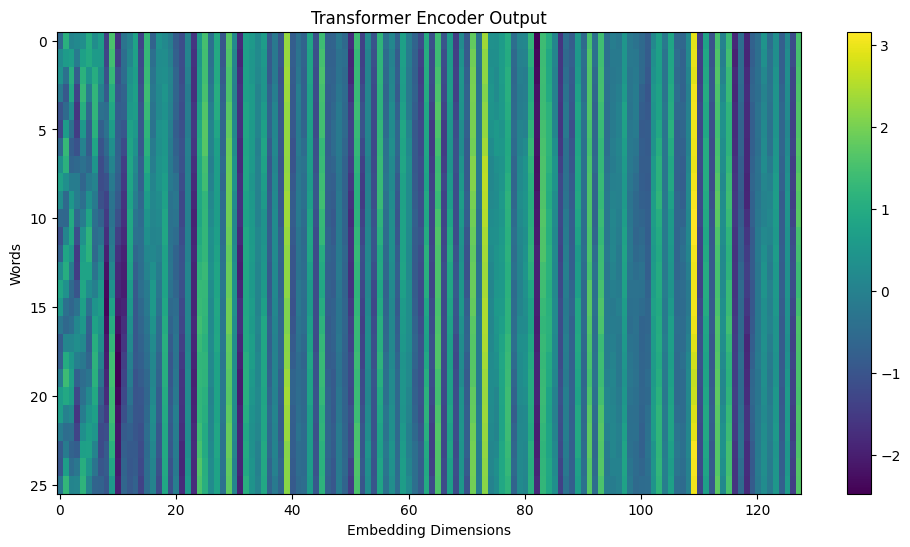


TRANSFORMER ENCODER ARCHITECTURE


Input
 ↓
Embedding
 ↓
Positional Encoding
 ↓
Multi-Head Attention
 ↓
Add & LayerNorm
 ↓
Feed Forward Network
 ↓
Add & LayerNorm
 ↓
Encoder Output



In [ ]:
# ============================================
# TASK 6: TRANSFORMER ENCODER
# ============================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Feed Forward Network
# --------------------------------------------------

class FeedForwardNetwork(tf.keras.layers.Layer):

    def __init__(self, d_model, dff):

        super().__init__()

        self.dense1 = tf.keras.layers.Dense(
            dff,
            activation='relu'
        )

        self.dense2 = tf.keras.layers.Dense(
            d_model
        )

    def call(self, x):

        x = self.dense1(x)

        x = self.dense2(x)

        return x


# --------------------------------------------------
# Multi Head Attention Layer
# --------------------------------------------------

class MultiHeadAttention(tf.keras.layers.Layer):

    def __init__(self, d_model, num_heads):

        super().__init__()

        self.num_heads = num_heads
        self.d_model = d_model

        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        self.WQ = tf.keras.layers.Dense(d_model)
        self.WK = tf.keras.layers.Dense(d_model)
        self.WV = tf.keras.layers.Dense(d_model)

        self.final_dense = tf.keras.layers.Dense(
            d_model
        )

    def split_heads(self, x, batch_size):

        x = tf.reshape(
            x,
            (
                batch_size,
                -1,
                self.num_heads,
                self.depth
            )
        )

        return tf.transpose(
            x,
            perm=[0,2,1,3]
        )

    def scaled_dot_product_attention(
        self,
        Q,
        K,
        V
    ):

        scores = tf.matmul(
            Q,
            K,
            transpose_b=True
        )

        dk = tf.cast(
            tf.shape(K)[-1],
            tf.float32
        )

        scores = scores / tf.math.sqrt(dk)

        attention_weights = tf.nn.softmax(
            scores,
            axis=-1
        )

        output = tf.matmul(
            attention_weights,
            V
        )

        return output, attention_weights

    def call(self, x):

        batch_size = tf.shape(x)[0]

        Q = self.WQ(x)
        K = self.WK(x)
        V = self.WV(x)

        Q = self.split_heads(
            Q,
            batch_size
        )

        K = self.split_heads(
            K,
            batch_size
        )

        V = self.split_heads(
            V,
            batch_size
        )

        attention_output, attention_weights = (
            self.scaled_dot_product_attention(
                Q,
                K,
                V
            )
        )

        attention_output = tf.transpose(
            attention_output,
            perm=[0,2,1,3]
        )

        concat_attention = tf.reshape(
            attention_output,
            (
                batch_size,
                -1,
                self.d_model
            )
        )

        output = self.final_dense(
            concat_attention
        )

        return output, attention_weights


# --------------------------------------------------
# Encoder Layer
# --------------------------------------------------

class EncoderLayer(tf.keras.layers.Layer):

    def __init__(
        self,
        d_model,
        num_heads,
        dff,
        dropout_rate=0.1
    ):

        super().__init__()

        self.mha = MultiHeadAttention(
            d_model,
            num_heads
        )

        self.ffn = FeedForwardNetwork(
            d_model,
            dff
        )

        self.layernorm1 = (
            tf.keras.layers.LayerNormalization(
                epsilon=1e-6
            )
        )

        self.layernorm2 = (
            tf.keras.layers.LayerNormalization(
                epsilon=1e-6
            )
        )

        self.dropout1 = tf.keras.layers.Dropout(
            dropout_rate
        )

        self.dropout2 = tf.keras.layers.Dropout(
            dropout_rate
        )

    def call(self, x, training=False):

        # -------------------------
        # Multi Head Attention
        # -------------------------

        attention_output, attention_weights = (
            self.mha(x)
        )

        attention_output = self.dropout1(
            attention_output,
            training=training
        )

        # Add & Norm
        out1 = self.layernorm1(
            x + attention_output
        )

        # -------------------------
        # Feed Forward Network
        # -------------------------

        ffn_output = self.ffn(out1)

        ffn_output = self.dropout2(
            ffn_output,
            training=training
        )

        # Add & Norm
        encoder_output = self.layernorm2(
            out1 + ffn_output
        )

        return (
            encoder_output,
            attention_weights
        )


# --------------------------------------------------
# Build Encoder Input
# --------------------------------------------------

sample_sentence = english_sentences[0]

print("Sentence:")
print(sample_sentence)

token_ids = eng_tokenizer.texts_to_sequences(
    [sample_sentence]
)

token_ids = tf.constant(token_ids)

embedded_sentence = eng_embedding(
    token_ids
)

seq_len = embedded_sentence.shape[1]

position_slice = pos_encoding[:seq_len]

encoder_input = (
    embedded_sentence +
    position_slice
)

print("\nEncoder Input Shape:")
print(encoder_input.shape)

# --------------------------------------------------
# Encoder Hyperparameters
# --------------------------------------------------

d_model = embedding_dim
num_heads = 4
dff = 512

# --------------------------------------------------
# Create Encoder Layer
# --------------------------------------------------

encoder = EncoderLayer(
    d_model=d_model,
    num_heads=num_heads,
    dff=dff
)

# --------------------------------------------------
# Forward Pass
# --------------------------------------------------

encoder_output, attention_weights = (
    encoder(
        encoder_input,
        training=False
    )
)

# --------------------------------------------------
# Results
# --------------------------------------------------

print("\nEncoder Output Shape:")
print(encoder_output.shape)

print("\nAttention Weights Shape:")
print(attention_weights.shape)

# --------------------------------------------------
# Visualize Encoder Output
# --------------------------------------------------

plt.figure(figsize=(12,6))

plt.imshow(
    encoder_output[0].numpy(),
    aspect='auto',
    cmap='viridis'
)

plt.colorbar()

plt.title(
    "Transformer Encoder Output"
)

plt.xlabel(
    "Embedding Dimensions"
)

plt.ylabel(
    "Words"
)

plt.show()

# --------------------------------------------------
# Architecture Summary
# --------------------------------------------------

print("\n===================================")
print("TRANSFORMER ENCODER ARCHITECTURE")
print("===================================\n")

print("""
Input
 ↓
Embedding
 ↓
Positional Encoding
 ↓
Multi-Head Attention
 ↓
Add & LayerNorm
 ↓
Feed Forward Network
 ↓
Add & LayerNorm
 ↓
Encoder Output
""")

###Task 7: Decoder Construction
Objective:
Build the Transformer Decoder.

Look Ahead Mask:
[[0. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]]
French Sentence:
<start> il a transformé notre vie il a transformé la société son fonctionnement la technologie moteur du changement accueil concepts enseignants recherche aperçu collaborateurs web hhcc ressources commentaires musée virtuel du canada <end>

Decoder Output Shape:
(1, 33, 128)

Output Probabilities Shape:
(1, 33, 41866)


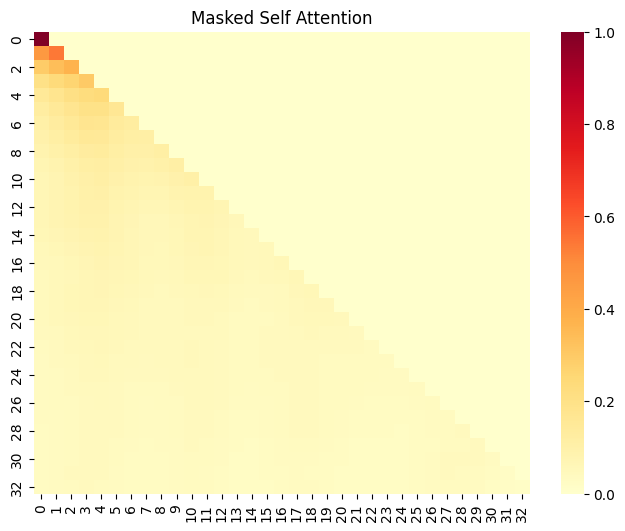

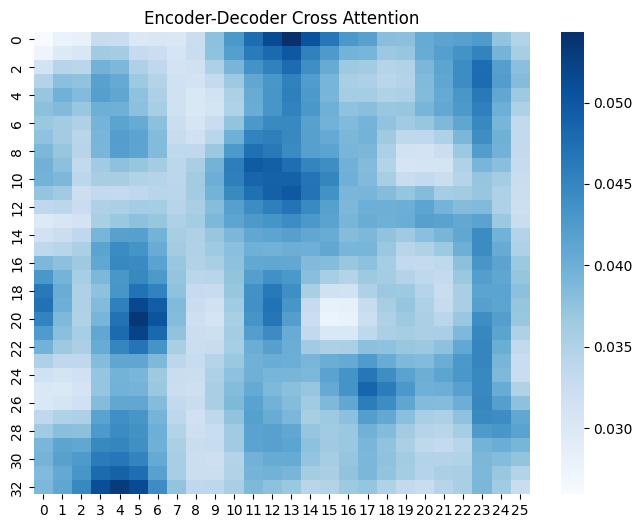


TRANSFORMER DECODER ARCHITECTURE


Previous French Words
        ↓
Masked Multi-Head Attention
        ↓
Add & LayerNorm
        ↓
Encoder-Decoder Attention
        ↓
Add & LayerNorm
        ↓
Feed Forward Network
        ↓
Add & LayerNorm
        ↓
Output Probabilities


TASK 7 COMPLETED


In [ ]:
# ============================================
# TASK 7: TRANSFORMER DECODER
# ============================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# Create Look-Ahead Mask
# --------------------------------------------------

def create_look_ahead_mask(size):

    mask = 1 - tf.linalg.band_part(
        tf.ones((size, size)),
        -1,
        0
    )

    return mask

# Example

mask = create_look_ahead_mask(5)

print("Look Ahead Mask:")
print(mask.numpy())

# --------------------------------------------------
# Multi Head Attention
# (supports optional mask)
# --------------------------------------------------

class MultiHeadAttention(tf.keras.layers.Layer):

    def __init__(self, d_model, num_heads):

        super().__init__()

        self.num_heads = num_heads
        self.d_model = d_model

        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        self.WQ = tf.keras.layers.Dense(d_model)
        self.WK = tf.keras.layers.Dense(d_model)
        self.WV = tf.keras.layers.Dense(d_model)

        self.final_dense = tf.keras.layers.Dense(
            d_model
        )

    def split_heads(self, x, batch_size):

        x = tf.reshape(
            x,
            (
                batch_size,
                -1,
                self.num_heads,
                self.depth
            )
        )

        return tf.transpose(
            x,
            perm=[0,2,1,3]
        )

    def scaled_dot_product_attention(
        self,
        Q,
        K,
        V,
        mask=None
    ):

        scores = tf.matmul(
            Q,
            K,
            transpose_b=True
        )

        dk = tf.cast(
            tf.shape(K)[-1],
            tf.float32
        )

        scores = scores / tf.math.sqrt(dk)

        if mask is not None:

            scores += (
                mask * -1e9
            )

        attention_weights = tf.nn.softmax(
            scores,
            axis=-1
        )

        output = tf.matmul(
            attention_weights,
            V
        )

        return output, attention_weights

    def call(
        self,
        Q_input,
        K_input,
        V_input,
        mask=None
    ):

        batch_size = tf.shape(Q_input)[0]

        Q = self.WQ(Q_input)
        K = self.WK(K_input)
        V = self.WV(V_input)

        Q = self.split_heads(
            Q,
            batch_size
        )

        K = self.split_heads(
            K,
            batch_size
        )

        V = self.split_heads(
            V,
            batch_size
        )

        attention_output, attention_weights = (
            self.scaled_dot_product_attention(
                Q,
                K,
                V,
                mask
            )
        )

        attention_output = tf.transpose(
            attention_output,
            perm=[0,2,1,3]
        )

        concat_attention = tf.reshape(
            attention_output,
            (
                batch_size,
                -1,
                self.d_model
            )
        )

        output = self.final_dense(
            concat_attention
        )

        return output, attention_weights


# --------------------------------------------------
# Feed Forward Network
# --------------------------------------------------

class FeedForwardNetwork(tf.keras.layers.Layer):

    def __init__(
        self,
        d_model,
        dff
    ):

        super().__init__()

        self.dense1 = tf.keras.layers.Dense(
            dff,
            activation='relu'
        )

        self.dense2 = tf.keras.layers.Dense(
            d_model
        )

    def call(self, x):

        x = self.dense1(x)

        x = self.dense2(x)

        return x


# --------------------------------------------------
# Decoder Layer
# --------------------------------------------------

class DecoderLayer(tf.keras.layers.Layer):

    def __init__(
        self,
        d_model,
        num_heads,
        dff,
        dropout_rate=0.1
    ):

        super().__init__()

        # Masked Self Attention
        self.masked_mha = MultiHeadAttention(
            d_model,
            num_heads
        )

        # Cross Attention
        self.cross_mha = MultiHeadAttention(
            d_model,
            num_heads
        )

        self.ffn = FeedForwardNetwork(
            d_model,
            dff
        )

        self.layernorm1 = (
            tf.keras.layers.LayerNormalization(
                epsilon=1e-6
            )
        )

        self.layernorm2 = (
            tf.keras.layers.LayerNormalization(
                epsilon=1e-6
            )
        )

        self.layernorm3 = (
            tf.keras.layers.LayerNormalization(
                epsilon=1e-6
            )
        )

        self.dropout1 = tf.keras.layers.Dropout(
            dropout_rate
        )

        self.dropout2 = tf.keras.layers.Dropout(
            dropout_rate
        )

        self.dropout3 = tf.keras.layers.Dropout(
            dropout_rate
        )

    def call(
        self,
        x,
        encoder_output,
        look_ahead_mask,
        training=False
    ):

        # ---------------------------------
        # 1. Masked Self Attention
        # ---------------------------------

        attn1, self_attention_weights = (
            self.masked_mha(
                x,
                x,
                x,
                look_ahead_mask
            )
        )

        attn1 = self.dropout1(
            attn1,
            training=training
        )

        out1 = self.layernorm1(
            x + attn1
        )

        # ---------------------------------
        # 2. Cross Attention
        # ---------------------------------

        attn2, cross_attention_weights = (
            self.cross_mha(
                out1,
                encoder_output,
                encoder_output
            )
        )

        attn2 = self.dropout2(
            attn2,
            training=training
        )

        out2 = self.layernorm2(
            out1 + attn2
        )

        # ---------------------------------
        # 3. Feed Forward
        # ---------------------------------

        ffn_output = self.ffn(
            out2
        )

        ffn_output = self.dropout3(
            ffn_output,
            training=training
        )

        decoder_output = self.layernorm3(
            out2 + ffn_output
        )

        return (
            decoder_output,
            self_attention_weights,
            cross_attention_weights
        )

# --------------------------------------------------
# Prepare Decoder Input
# --------------------------------------------------

sample_french = french_sentences[0]

print("French Sentence:")
print(sample_french)

decoder_tokens = (
    fr_tokenizer.texts_to_sequences(
        [sample_french]
    )
)

decoder_tokens = tf.constant(
    decoder_tokens
)

decoder_embedding = fr_embedding(
    decoder_tokens
)

decoder_seq_len = (
    decoder_embedding.shape[1]
)

decoder_position = (
    pos_encoding[:decoder_seq_len]
)

decoder_input = (
    decoder_embedding +
    decoder_position
)

# --------------------------------------------------
# Encoder Output
# (From Task 6)
# --------------------------------------------------

encoder_output = encoder_output

# --------------------------------------------------
# Look Ahead Mask
# --------------------------------------------------

look_ahead_mask = (
    create_look_ahead_mask(
        decoder_seq_len
    )
)

look_ahead_mask = look_ahead_mask[
    tf.newaxis,
    tf.newaxis,
    :,
    :
]

# --------------------------------------------------
# Create Decoder
# --------------------------------------------------

decoder = DecoderLayer(
    d_model=embedding_dim,
    num_heads=4,
    dff=512
)

# --------------------------------------------------
# Forward Pass
# --------------------------------------------------

(
    decoder_output,
    self_attention_weights,
    cross_attention_weights
) = decoder(
    decoder_input,
    encoder_output,
    look_ahead_mask,
    training=False
)

print("\nDecoder Output Shape:")
print(decoder_output.shape)

# --------------------------------------------------
# Output Probabilities
# --------------------------------------------------

output_layer = tf.keras.layers.Dense(
    fr_vocab_size,
    activation='softmax'
)

output_probabilities = (
    output_layer(
        decoder_output
    )
)

print(
    "\nOutput Probabilities Shape:"
)

print(
    output_probabilities.shape
)

# --------------------------------------------------
# Visualize Masked Attention
# --------------------------------------------------

plt.figure(figsize=(8,6))

sns.heatmap(
    self_attention_weights[0][0].numpy(),
    cmap="YlOrRd"
)

plt.title(
    "Masked Self Attention"
)

plt.show()

# --------------------------------------------------
# Visualize Cross Attention
# --------------------------------------------------

plt.figure(figsize=(8,6))

sns.heatmap(
    cross_attention_weights[0][0].numpy(),
    cmap="Blues"
)

plt.title(
    "Encoder-Decoder Cross Attention"
)

plt.show()

# --------------------------------------------------
# Architecture Summary
# --------------------------------------------------

print("\n===================================")
print("TRANSFORMER DECODER ARCHITECTURE")
print("===================================\n")

print("""
Previous French Words
        ↓
Masked Multi-Head Attention
        ↓
Add & LayerNorm
        ↓
Encoder-Decoder Attention
        ↓
Add & LayerNorm
        ↓
Feed Forward Network
        ↓
Add & LayerNorm
        ↓
Output Probabilities
""")

print("\n===================================")
print("TASK 7 COMPLETED")
print("===================================")

###Full Transformer model

In [ ]:

# ===== PATCH FOR TASK 8 =====
# Run this cell BEFORE Task 8

class EncoderLayer(tf.keras.layers.Layer):

    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()

        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForwardNetwork(d_model, dff)

        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, training=False):

        attention_output, attention_weights = self.mha(
            x, x, x
        )

        attention_output = self.dropout1(
            attention_output,
            training=training
        )

        out1 = self.layernorm1(
            x + attention_output
        )

        ffn_output = self.ffn(out1)

        ffn_output = self.dropout2(
            ffn_output,
            training=training
        )

        encoder_output = self.layernorm2(
            out1 + ffn_output
        )

        return encoder_output, attention_weights


(5000, 40)
(5000, 39)
(5000, 39)
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.6347 - loss: 3.9710
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.6676 - loss: 2.4476
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6774 - loss: 2.2457
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.6879 - loss: 2.0507
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.7034 - loss: 1.8484


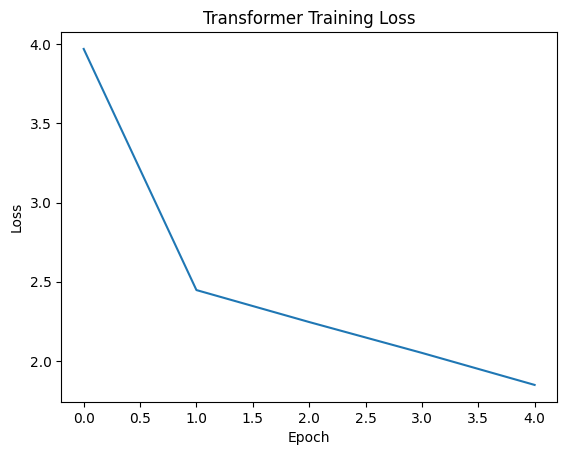

In [ ]:
#Data Preparation for Training
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
import numpy as np

MAX_LEN = 40

eng_sequences = eng_tokenizer.texts_to_sequences(
    english_sentences[:5000]
)

fr_sequences = fr_tokenizer.texts_to_sequences(
    french_sentences[:5000]
)

encoder_inputs = pad_sequences(
    eng_sequences,
    maxlen=MAX_LEN,
    padding='post'
)

decoder_full = pad_sequences(
    fr_sequences,
    maxlen=MAX_LEN,
    padding='post'
)

decoder_inputs = decoder_full[:, :-1]

decoder_targets = decoder_full[:, 1:]

print(encoder_inputs.shape)
print(decoder_inputs.shape)
print(decoder_targets.shape)

#Vocabulary Sizes
SRC_VOCAB_SIZE = len(
    eng_tokenizer.word_index
) + 1

TGT_VOCAB_SIZE = len(
    fr_tokenizer.word_index
) + 1

# --- Corrected EncoderLayer definition start ---
# This corrected EncoderLayer is from the patch cell 62d391ae
class EncoderLayer(tf.keras.layers.Layer):

    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()

        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForwardNetwork(d_model, dff)

        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, training=False):

        attention_output, attention_weights = self.mha(
            x, x, x # Corrected: passing x for Q, K, V
        )

        attention_output = self.dropout1(
            attention_output,
            training=training
        )

        out1 = self.layernorm1(
            x + attention_output
        )

        ffn_output = self.ffn(out1)

        ffn_output = self.dropout2(
            ffn_output,
            training=training
        )

        encoder_output = self.layernorm2(
            out1 + ffn_output
        )

        return encoder_output, attention_weights
# --- Corrected EncoderLayer definition end ---

#Full Transformer Model
class Transformer(tf.keras.Model):

    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model,
        num_heads,
        dff
    ):

        super().__init__()

        self.encoder_embedding = (
            tf.keras.layers.Embedding(
                src_vocab_size,
                d_model
            )
        )

        self.decoder_embedding = (
            tf.keras.layers.Embedding(
                tgt_vocab_size,
                d_model
            )
        )

        self.encoder = EncoderLayer(
            d_model,
            num_heads,
            dff
        )

        self.decoder = DecoderLayer(
            d_model,
            num_heads,
            dff
        )

        self.final_layer = (
            tf.keras.layers.Dense(
                tgt_vocab_size
            )
        )

    def call(self, inputs):

        encoder_input, decoder_input = inputs

        # Encoder Embedding

        enc_embed = self.encoder_embedding(
            encoder_input
        )

        enc_len = tf.shape(
            encoder_input
        )[1]

        enc_embed = (
            enc_embed +
            pos_encoding[:enc_len]
        )

        encoder_output, _ = (
            self.encoder(
                enc_embed
            )
        )

        # Decoder Embedding

        dec_embed = self.decoder_embedding(
            decoder_input
        )

        dec_len = tf.shape(
            decoder_input
        )[1]

        dec_embed = (
            dec_embed +
            pos_encoding[:dec_len]
        )

        mask = create_look_ahead_mask(
            dec_len
        )

        mask = mask[
            tf.newaxis,
            tf.newaxis,
            :,
            :
        ]

        decoder_output, _, _ = (
            self.decoder(
                dec_embed,
                encoder_output,
                mask
            )
        )

        output = self.final_layer(
            decoder_output
        )

        return output
#Create Model
D_MODEL = embedding_dim
NUM_HEADS = 4
DFF = 512

model = Transformer(
    SRC_VOCAB_SIZE,
    TGT_VOCAB_SIZE,
    D_MODEL,
    NUM_HEADS,
    DFF
)
#Loss Function
loss_fn = (
    tf.keras.losses.
    SparseCategoricalCrossentropy(
        from_logits=True
    )
)
#Compile
model.compile(
    optimizer='adam',
    loss=loss_fn,
    metrics=['accuracy']
)
#Train
history = model.fit(
    (
        encoder_inputs,
        decoder_inputs
    ),
    decoder_targets,
    batch_size=32,
    epochs=5
)
#Plot Loss
import matplotlib.pyplot as plt

plt.plot(
    history.history['loss']
)

plt.title(
    "Transformer Training Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [ ]:
# ============================================
# TASK 9 : TRANSLATION GENERATION
# ============================================

import tensorflow as tf
import numpy as np

# ----------------------------------
# Reverse French Vocabulary
# ----------------------------------

fr_index_word = {
    index: word
    for word, index
    in fr_tokenizer.word_index.items()
}

# ----------------------------------
# Translation Function
# ----------------------------------

def translate(sentence):

    print("Input Sentence:")
    print(sentence)

    # -----------------------------
    # Encode English Sentence
    # -----------------------------

    input_seq = eng_tokenizer.texts_to_sequences(
        [sentence.lower()]
    )

    input_seq = tf.keras.preprocessing.sequence.pad_sequences(
        input_seq,
        maxlen=MAX_LEN,
        padding='post'
    )

    # -----------------------------
    # Start Token
    # -----------------------------

    start_token = fr_tokenizer.word_index["start"]

    end_token = fr_tokenizer.word_index["end"]

    decoder_input = [[start_token]]

    generated_words = []

    print("\nGeneration Process:")

    # -----------------------------
    # Generate Word by Word
    # -----------------------------

    for step in range(MAX_LEN):

        prediction = model(
            (
                input_seq,
                np.array(decoder_input)
            ),
            training=False
        )

        next_token = tf.argmax(
            prediction[:, -1, :],
            axis=-1
        ).numpy()[0]

        if next_token == end_token:
            print("<end>")
            break

        word = fr_index_word.get(
            next_token,
            "<unk>"
        )

        generated_words.append(word)

        print(" ".join(generated_words))

        decoder_input[0].append(
            next_token
        )

    return " ".join(generated_words)

# ----------------------------------
# Test Translation
# ----------------------------------

translated_text = translate(
    "the cat chased the mouse"
)

print("\nFinal Translation:")
print(translated_text)

Input Sentence:
the cat chased the mouse

Generation Process:
de
de la
de la lumière
de la lumière est
de la lumière est le
de la lumière est le canada
de la lumière est le canada <end>
de la lumière est le canada <end> <unk>
de la lumière est le canada <end> <unk> <unk>
de la lumière est le canada <end> <unk> <unk> <unk>
de la lumière est le canada <end> <unk> <unk> <unk> <unk>
de la lumière est le canada <end> <unk> <unk> <unk> <unk> <unk>
de la lumière est le canada <end> <unk> <unk> <unk> <unk> <unk> <unk>
de la lumière est le canada <end> <unk> <unk> <unk> <unk> <unk> <unk> <unk>
de la lumière est le canada <end> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>
de la lumière est le canada <end> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>
de la lumière est le canada <end> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>
de la lumière est le canada <end> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>
de la lumière est le canada <end> <unk> <unk

In [ ]:
from nltk.translate.bleu_score import (
    sentence_bleu,
    SmoothingFunction
)

import pandas as pd

###Evaluation

In [ ]:
# ============================================
# TASK 10 : BLEU SCORE EVALUATION
# ============================================

smooth = SmoothingFunction().method1

def evaluate_bleu(
    reference_sentence,
    predicted_sentence
):

    reference = [
        reference_sentence.lower().split()
    ]

    candidate = (
        predicted_sentence.lower().split()
    )

    bleu = sentence_bleu(
        reference,
        candidate,
        smoothing_function=smooth
    )

    return bleu

In [ ]:
actual = (
    "le chat a poursuivi la souris"
)

predicted = (
    "le chat a poursuivi la souris"
)

bleu = evaluate_bleu(
    actual,
    predicted
)

print("Actual:")
print(actual)

print("\nPredicted:")
print(predicted)

print("\nBLEU Score:")
print(round(bleu,4))

Actual:
le chat a poursuivi la souris

Predicted:
le chat a poursuivi la souris

BLEU Score:
1.0
